## Predicción de los Arrestos en los crímenes de Chigado
Este es el Notebook de Clasificación


Listo al 18/01/25 2:31am

Dataset: Chicago_crimes_2021_2017

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.model_selection import train_test_split
%matplotlib inline

## MODELOS DE CLASIFICACIÓN

### **Preprocesamiento de la submuestra**

Lectura del dataset que contiene la información de datos de entrenamiento y prueba (x,y)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, recall_score, roc_curve, auc, precision_recall_curve, accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, precision_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV

In [ ]:
# Leer los datos desde los archivos CSV
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [ ]:
# Características categóricas y numéricas
categorical_features = ['Primary Type']
numerical_features = ['Beat', 'District', 'Ward','Community Area','Year', 'Hour', 'Month','Latitude','Longitude']

# Codificacion One-Hot y  escalado estándar
preprocessor = ColumnTransformer(
  transformers=[
      ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
      ('num', MinMaxScaler(), numerical_features)
  ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Shape of X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"Shape of X_test_preprocessed: {X_test_preprocessed.shape}")

Shape of X_train_preprocessed: (19905, 37)
Shape of X_test_preprocessed: (8532, 37)


In [ ]:
def mostrar_metricas(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    print(f"Accuracy: {accuracy}")
    print(f"Balanced Accuracy: {balanced_accuracy}")
    print(f"Recall: {recall}")
    print(f"Precision: {precision}")
    print(f"F1 Score: {f1}")

In [ ]:
def mostrar_matriz_confusion(y_test, y_pred):
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    return conf_matrix


### RANDOM FOREST





**Sin Tuneo de Hyper - Parámetros**

In [ ]:
modelRF0 = RandomForestClassifier()
modelRF0.fit(X_train_preprocessed, y_train)

y_predRF0 = modelRF0.predict(X_test_preprocessed)
y_probRF0 = modelRF0.predict_proba(X_test_preprocessed)[:, 1]

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
print(classification_report(y_test, y_predRF0))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      6302
           1       0.78      0.56      0.65      2230

    accuracy                           0.84      8532
   macro avg       0.82      0.75      0.78      8532
weighted avg       0.84      0.84      0.84      8532



In [ ]:
mostrar_metricas(y_test, y_predRF0)

Accuracy: 0.8444678856071262
Balanced Accuracy: 0.7533176171562022
Recall: 0.5623318385650224
Precision: 0.7813084112149533
F1 Score: 0.6539765319426336


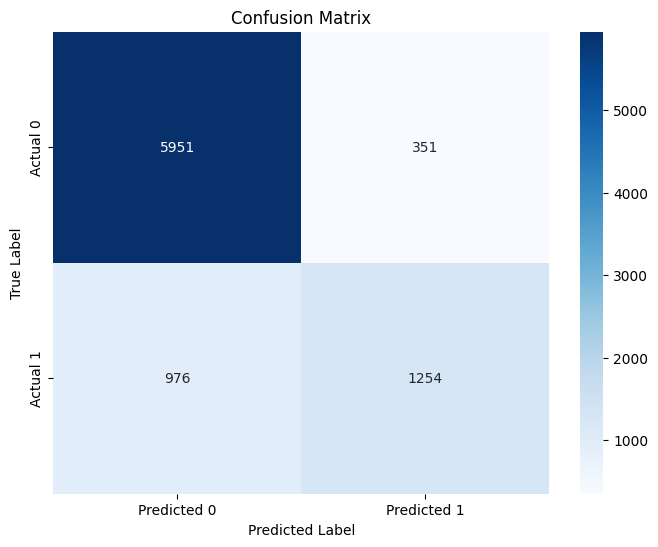

array([[5951,  351],
       [ 976, 1254]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predRF0)

#### **Tuneo de Hiperparámetros**
Mediante GridSearch para seleccionar mejor configuración**

In [ ]:
# Tuneo de Hiperparametros
'''param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_classifier = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='f1', verbose=1, n_jobs=-1)

grid_search.fit(X_train_preprocessed, y_train)

best_rf_model = grid_search.best_estimator_

print(f"Best Parameters: {best_rf_model}")'''

'param_grid = {\n    \'n_estimators\': [50, 100, 200],\n    \'max_depth\': [None, 10, 20],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4]\n}\n\nrf_classifier = RandomForestClassifier(random_state=42, class_weight=\'balanced\')\n\ngrid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring=\'f1\', verbose=1, n_jobs=-1)\n\ngrid_search.fit(X_train_preprocessed, y_train)\n\nbest_rf_model = grid_search.best_estimator_\n\nprint(f"Best Parameters: {best_rf_model}")'

In [ ]:
#Creación del modelo.
modelRF = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42, class_weight='balanced')
modelRF.fit(X_train_preprocessed, y_train)
y_predRF = modelRF.predict(X_test_preprocessed)
y_probRF = modelRF.predict_proba(X_test_preprocessed)[:, 1]


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
mostrar_metricas(y_test, y_predRF)

Accuracy: 0.8492733239568683
Balanced Accuracy: 0.764248946522778
Recall: 0.5860986547085202
Precision: 0.7826347305389222
F1 Score: 0.6702564102564103


In [ ]:
print(classification_report(y_test, y_predRF))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      6302
           1       0.78      0.59      0.67      2230

    accuracy                           0.85      8532
   macro avg       0.82      0.76      0.79      8532
weighted avg       0.84      0.85      0.84      8532



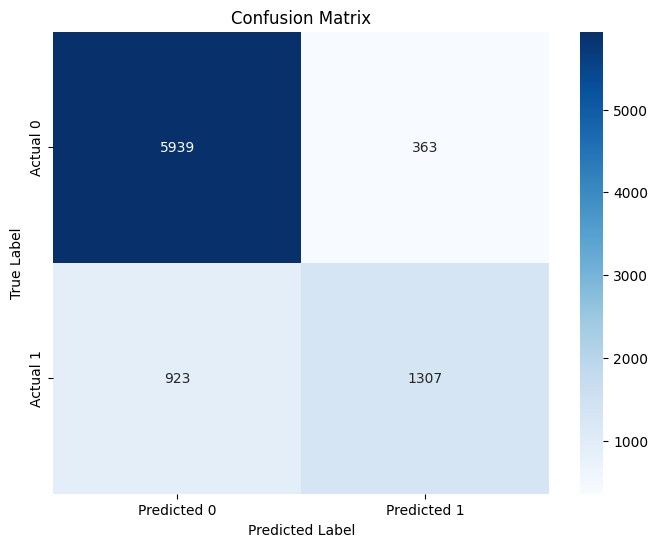

array([[5939,  363],
       [ 923, 1307]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predRF)

### GRADIENT BOOSTING

**Sin Tuneo de Hyper - Parámetros**

In [ ]:
modelGB0 = GradientBoostingClassifier()
modelGB0.fit(X_train_preprocessed, y_train)

y_predGB0 = modelGB0.predict(X_test_preprocessed)
y_probGB0 = modelGB0.predict_proba(X_test_preprocessed)[:, 1]

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print(classification_report(y_test, y_predGB0))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      6302
           1       0.91      0.52      0.66      2230

    accuracy                           0.86      8532
   macro avg       0.88      0.75      0.79      8532
weighted avg       0.87      0.86      0.85      8532



In [ ]:
mostrar_metricas(y_test, y_predGB0)

Accuracy: 0.8620487576183778
Balanced Accuracy: 0.752759320480508
Recall: 0.5237668161434977
Precision: 0.9103663289166017
F1 Score: 0.6649587247366923


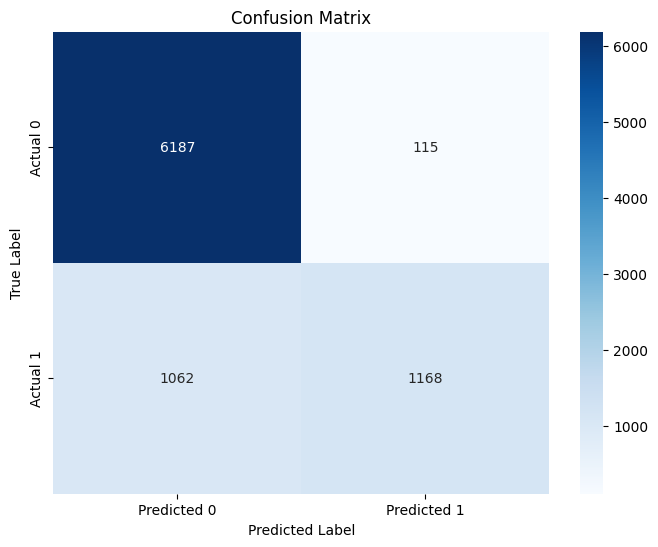

array([[6187,  115],
       [1062, 1168]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predGB0)

**Grid Search para sleección de hyper-parámetros**

In [ ]:
# Tuneo de Hiperparametros
'''param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],  # Step size shrinkage used in update to prevents overfitting
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

gb_classifier = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(gb_classifier, param_grid, cv=5, scoring='roc_auc', n_jobs=-1) # Use ROC AUC for scoring

grid_search.fit(X_train_preprocessed, y_train)

best_gb_model = grid_search.best_estimator_

print(f"Best Parameters: {best_gb_model}")'''

'param_grid = {\n    \'n_estimators\': [50, 100, 200],\n    \'learning_rate\': [0.01, 0.1, 1],  # Step size shrinkage used in update to prevents overfitting\n    \'max_depth\': [3, 5, 7],\n    \'min_samples_split\': [2, 5, 10], # Minimum number of samples required to split an internal node\n    \'min_samples_leaf\': [1, 2, 4] # Minimum number of samples required to be at a leaf node\n}\n\ngb_classifier = GradientBoostingClassifier(random_state=42)\n\ngrid_search = GridSearchCV(gb_classifier, param_grid, cv=5, scoring=\'roc_auc\', n_jobs=-1) # Use ROC AUC for scoring\n\ngrid_search.fit(X_train_preprocessed, y_train)\n\nbest_gb_model = grid_search.best_estimator_\n\nprint(f"Best Parameters: {best_gb_model}")'

**Método Bossting con mejores hiperparametro**

In [ ]:
# Crear Modelo
modelGB = GradientBoostingClassifier(max_depth=5, min_samples_leaf=2, n_estimators=200, random_state=42)
modelGB.fit(X_train_preprocessed, y_train)

#Predicción
y_predGB = modelGB.predict(X_test_preprocessed)
y_probGB = modelGB.predict_proba(X_test_preprocessed)[:, 1]



/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print(classification_report(y_test, y_predGB))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      6302
           1       0.92      0.53      0.67      2230

    accuracy                           0.86      8532
   macro avg       0.89      0.75      0.79      8532
weighted avg       0.87      0.86      0.85      8532



In [ ]:
mostrar_metricas(y_test, y_predGB)

Accuracy: 0.8635724331926864
Balanced Accuracy: 0.7545151158504738
Recall: 0.5260089686098655
Precision: 0.91640625
F1 Score: 0.6683760683760683


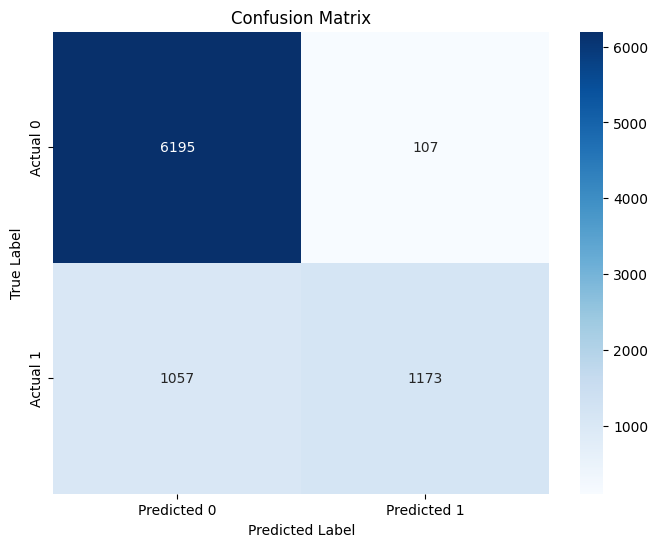

array([[6195,  107],
       [1057, 1173]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predGB)

### DECISSION TREE

**Sin tuneo de Hyper - Parámetros**

In [ ]:
modelDT0 = DecisionTreeClassifier()
modelDT0.fit(X_train_preprocessed, y_train)

#Predicción
y_predDT0 = modelDT0.predict(X_test_preprocessed)
y_probDT0 = modelDT0.predict_proba(X_test_preprocessed)[:, 1]

In [ ]:
print(classification_report(y_test, y_predDT0))


              precision    recall  f1-score   support

           0       0.86      0.86      0.86      6302
           1       0.61      0.61      0.61      2230

    accuracy                           0.80      8532
   macro avg       0.74      0.74      0.74      8532
weighted avg       0.80      0.80      0.80      8532



In [ ]:
mostrar_metricas(y_test, y_predDT0)

Accuracy: 0.7955930614158462
Balanced Accuracy: 0.7352999190235003
Recall: 0.6089686098654709
Precision: 0.6089686098654709
F1 Score: 0.6089686098654709


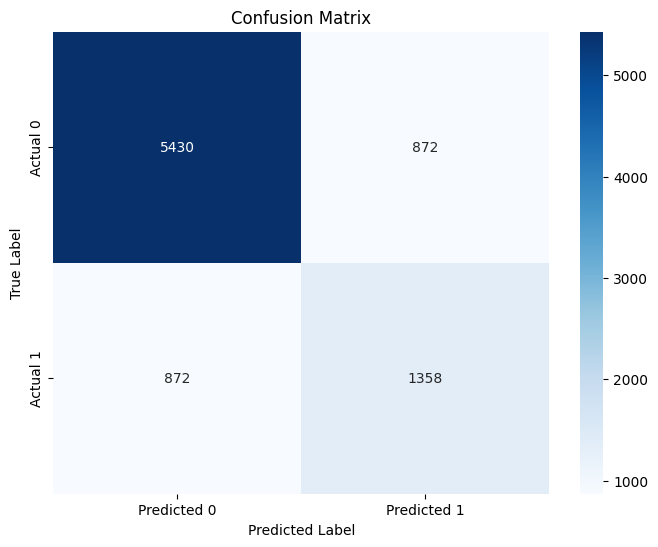

array([[5430,  872],
       [ 872, 1358]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predDT0)

**Tuneo de Hyper - Parámetros**

In [ ]:
#Tuneo de Hyperparamtros
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_classifier = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(dt_classifier, param_grid, cv=5, scoring='balanced_accuracy', n_jobs=-1)

grid_search.fit(X_train_preprocessed, y_train)

best_dt_model= grid_search.best_estimator_

print(f"Best Parameters: {best_dt_model}")

Best Parameters: DecisionTreeClassifier(max_depth=10, random_state=42)


In [ ]:
#Predicción
modelDT = DecisionTreeClassifier(criterion='gini', max_depth=20, min_samples_leaf=2, min_samples_split=2, random_state=42)
modelDT.fit(X_train_preprocessed, y_train)
y_predDT = modelDT.predict(X_test_preprocessed)
y_probDT = modelDT.predict_proba(X_test_preprocessed)[:, 1]


In [ ]:
print(classification_report(y_test, y_predDT))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      6302
           1       0.80      0.52      0.63      2230

    accuracy                           0.84      8532
   macro avg       0.83      0.74      0.77      8532
weighted avg       0.84      0.84      0.83      8532



In [ ]:
mostrar_metricas(y_test, y_predDT)

Accuracy: 0.8413033286451008
Balanced Accuracy: 0.7377020320974337
Recall: 0.520627802690583
Precision: 0.8029045643153527
F1 Score: 0.6316648531011969


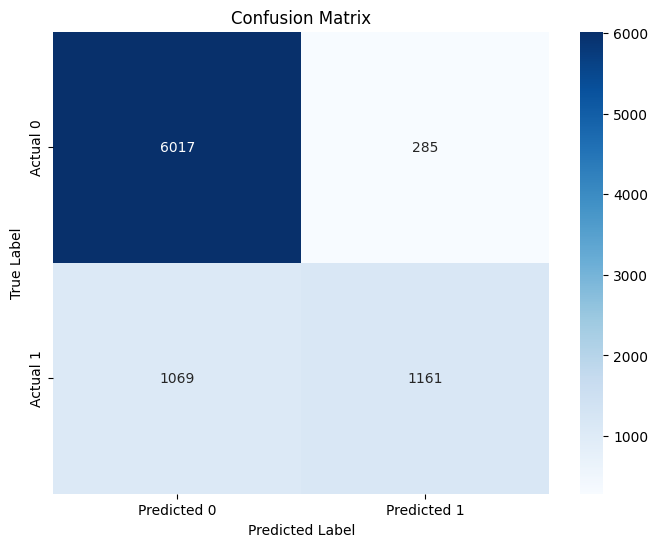

array([[6017,  285],
       [1069, 1161]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predDT)

### LOGISTIC REGRESSION

**Sin Tuneo de Hyper Parámetros**

In [ ]:
modelLR0 = LogisticRegression()
modelLR0.fit(X_train_preprocessed, y_train)

y_predLR0 = modelLR0.predict(X_test_preprocessed)
y_probLR0 = modelLR0.predict_proba(X_test_preprocessed)[:, 1] # Probabilities for the positive class

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print(classification_report(y_test, y_predLR0))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      6302
           1       0.91      0.52      0.67      2230

    accuracy                           0.86      8532
   macro avg       0.88      0.75      0.79      8532
weighted avg       0.87      0.86      0.85      8532



In [ ]:
mostrar_metricas(y_test, y_predLR0)

Accuracy: 0.8626347866854196
Balanced Accuracy: 0.7534457706500748
Recall: 0.5246636771300448
Precision: 0.9126365054602185
F1 Score: 0.6662870159453302


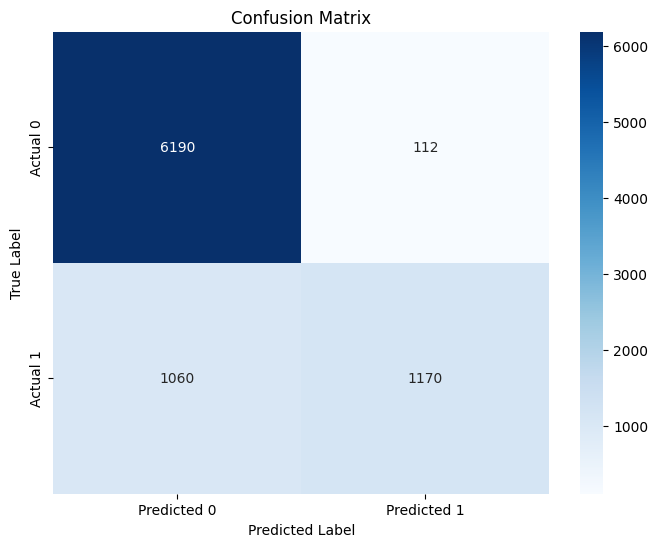

array([[6190,  112],
       [1060, 1170]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predLR0)

**Grid Search para sleección de hyper-parámetros**

In [ ]:
'''
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver':['saga'] # Solvers that support L1 and L2
}

grid_search = GridSearchCV(LogisticRegression(max_iter=10000, class_weight='balanced'), param_grid, cv=5, scoring='balanced_accuracy')

grid_search.fit(X_train_preprocessed, y_train)

best_model = grid_search.best_estimator_

print(f"Best Parameters: {best_model}")'''

'\nparam_grid = {\n    \'C\': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength\n    \'penalty\': [\'l1\', \'l2\'],  # Regularization type\n    \'solver\':[\'saga\'] # Solvers that support L1 and L2\n}\n\ngrid_search = GridSearchCV(LogisticRegression(max_iter=10000, class_weight=\'balanced\'), param_grid, cv=5, scoring=\'balanced_accuracy\')\n\ngrid_search.fit(X_train_preprocessed, y_train)\n\nbest_model = grid_search.best_estimator_\n\nprint(f"Best Parameters: {best_model}")'

**Método Logistic Regression con mejores hiperparametro**

In [ ]:
# Creacion y Evaluacion de Modelo
modelLR = LogisticRegression(C=0.1, class_weight='balanced', max_iter=10000,penalty='l1',solver='saga')
modelLR.fit(X_train_preprocessed,y_train)
y_predLR = modelLR.predict(X_test_preprocessed)
y_prob_LR = modelLR.predict_proba(X_test_preprocessed)[:, 1] # Probabilities for the positive class


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print(classification_report(y_test, y_predLR))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      6302
           1       0.91      0.52      0.67      2230

    accuracy                           0.86      8532
   macro avg       0.88      0.75      0.79      8532
weighted avg       0.87      0.86      0.85      8532



In [ ]:
mostrar_metricas(y_test, y_predLR)

Accuracy: 0.8626347866854196
Balanced Accuracy: 0.7534457706500748
Recall: 0.5246636771300448
Precision: 0.9126365054602185
F1 Score: 0.6662870159453302


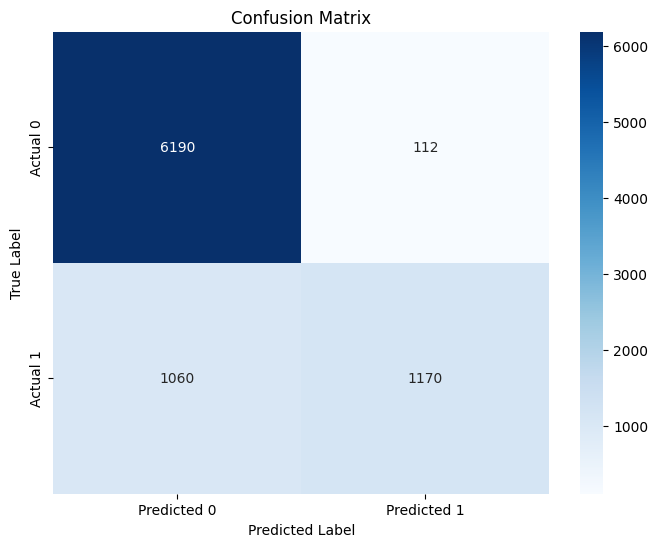

array([[6190,  112],
       [1060, 1170]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predLR)

### SUPORT VECTORS MACHINE

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

**Sin Tuneo de Hyper - Parametros**

In [ ]:
#Crear Modelo
modelSV0 = SVC()
modelSV0.fit(X_train_preprocessed,y_train)

# Prediccion
y_predSV0 = modelSV0.predict(X_test_preprocessed)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print(classification_report(y_test, y_predSV0))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      6302
           1       0.91      0.52      0.67      2230

    accuracy                           0.86      8532
   macro avg       0.88      0.75      0.79      8532
weighted avg       0.87      0.86      0.85      8532



In [ ]:
mostrar_metricas(y_test, y_predSV0)

Accuracy: 0.8626347866854196
Balanced Accuracy: 0.7534457706500748
Recall: 0.5246636771300448
Precision: 0.9126365054602185
F1 Score: 0.6662870159453302


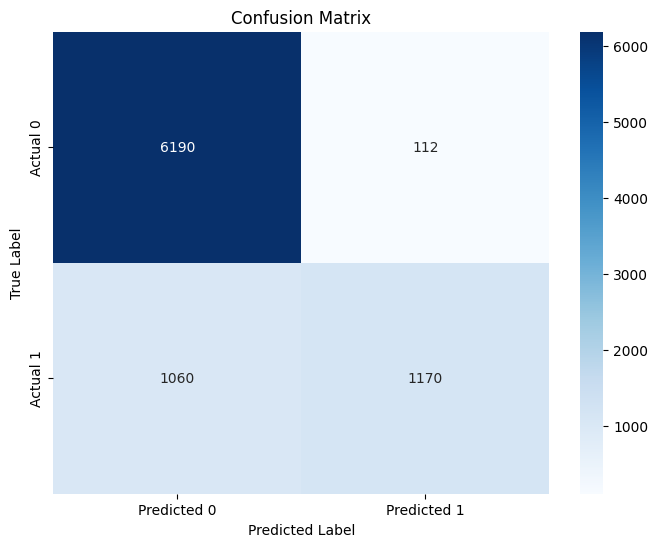

array([[6190,  112],
       [1060, 1170]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predSV0)

**Ajuste de hyper-parámetros**

In [ ]:
'''
param_grid = {
    'C': [0.1, 1, 10],  # Parámetro de regularización
    'gamma': [0.1, 0.01, 0.001],  # Parámetro del kernel
    'kernel': ['rbf', 'linear']  # Tipo de kernel
}

grid = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=3, scoring='balanced_accuracy', cv=5)  # Usa balanced_accuracy
grid.fit(X_test_preprocessed, y_train)
print(grid.best_params_)'''

"\nparam_grid = {\n    'C': [0.1, 1, 10],  # Parámetro de regularización\n    'gamma': [0.1, 0.01, 0.001],  # Parámetro del kernel\n    'kernel': ['rbf', 'linear']  # Tipo de kernel\n}\n\ngrid = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=3, scoring='balanced_accuracy', cv=5)  # Usa balanced_accuracy\ngrid.fit(X_test_preprocessed, y_train)\nprint(grid.best_params_)"

**SVM con mejores hiperparámetros**

In [ ]:
#Crear Modelo
modelSV = SVC(C=1, gamma= 0.1, kernel='linear',probability=True)
modelSV.fit(X_train_preprocessed,y_train)

# Prediccion
y_predSV = modelSV.predict(X_test_preprocessed)
y_prob_SV = modelSV.predict_proba(X_test_preprocessed)[:,1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
print(classification_report(y_test, y_predSV))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      6302
           1       0.91      0.53      0.67      2230

    accuracy                           0.86      8532
   macro avg       0.88      0.75      0.79      8532
weighted avg       0.87      0.86      0.85      8532



In [ ]:
mostrar_metricas(y_test, y_predSV)

Accuracy: 0.862751992498828
Balanced Accuracy: 0.7536699858967115
Recall: 0.5251121076233184
Precision: 0.9127045985970382
F1 Score: 0.6666666666666666


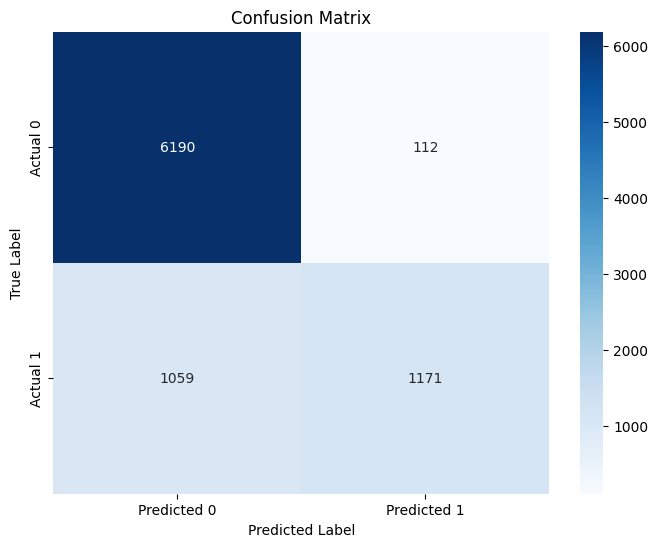

array([[6190,  112],
       [1059, 1171]])

In [ ]:
mostrar_matriz_confusion(y_test, y_predSV)

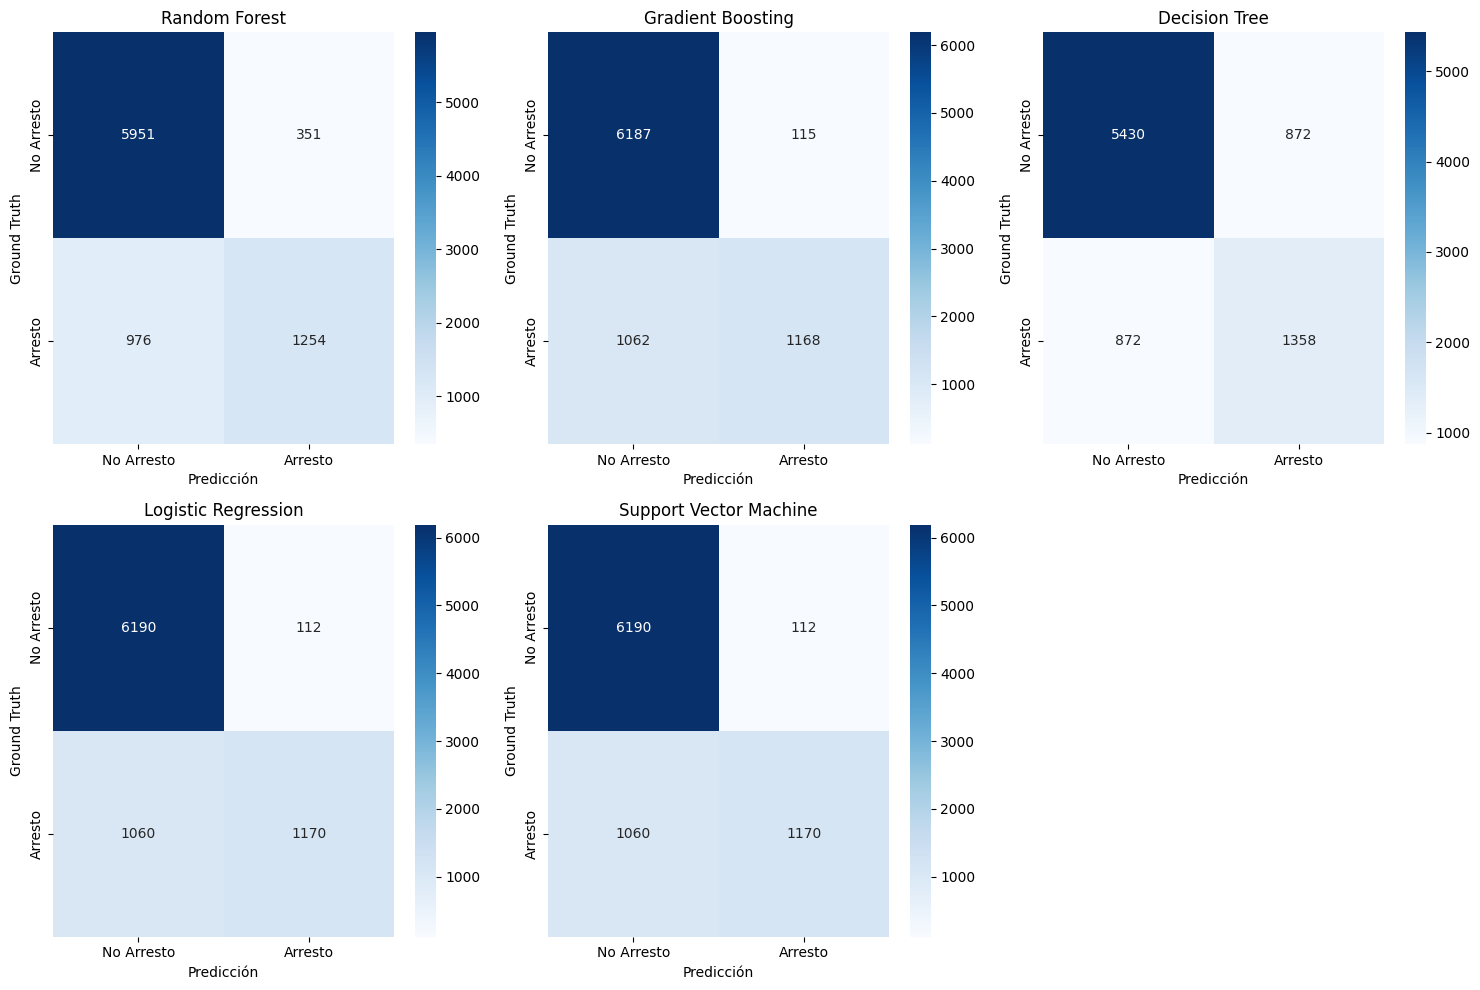

In [ ]:
#Matrices de Modelos sin Tuneo

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(models, X_test, y_test):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()  # Flatten the axes array

    model_names = ['Random Forest', 'Gradient Boosting', 'Decision Tree','Logistic Regression','Support Vector Machine']
    model_predictions = [y_predRF0, y_predGB0, y_predDT0, y_predLR0, y_predSV0]


    for i, (name, y_pred) in enumerate(zip(model_names, model_predictions)):
        conf_matrix = confusion_matrix(y_test, y_pred)
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['No Arresto', 'Arresto'],
                    yticklabels=['No Arresto', 'Arresto'], ax=axes[i])
        axes[i].set_title(f"{name}")
        axes[i].set_xlabel("Predicción")
        axes[i].set_ylabel("Ground Truth")

    # Hide any unused subplots if less than 6 models are provided
    for j in range(len(model_names), len(axes)):
      fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_confusion_matrices([modelRF, modelGB, modelDT, modelLR, modelSV], X_test_preprocessed, y_test)

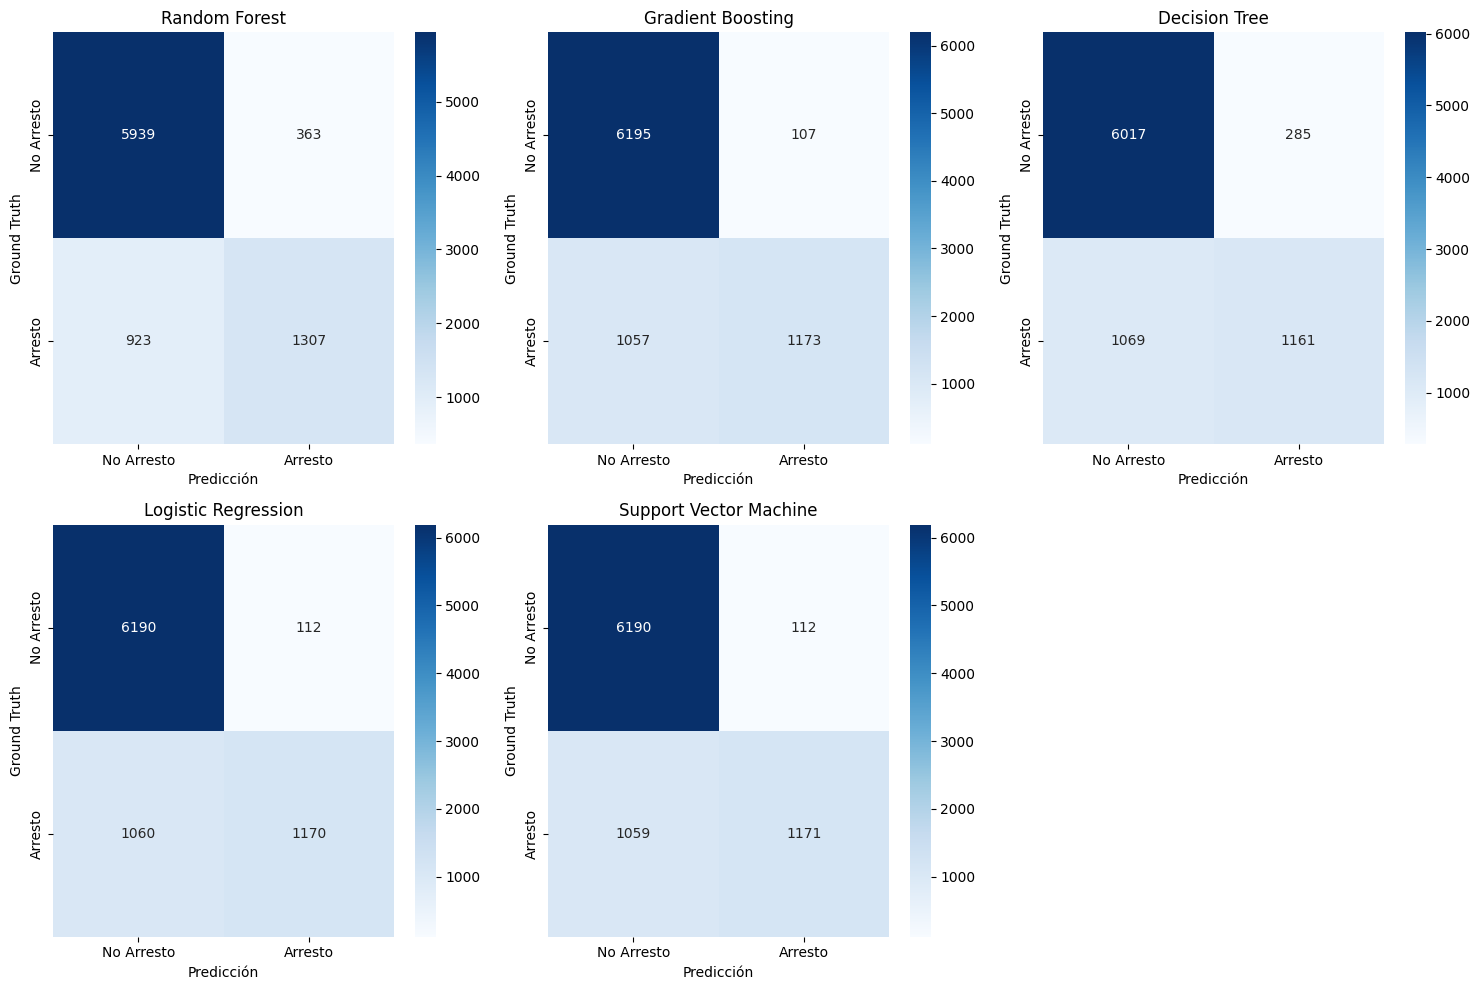

In [ ]:
# prompt: muestra todas las matrices de confusión  de los modelos con hiperparametros en una figura de 2 filas

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(models, X_test, y_test):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()  # Flatten the axes array

    model_names = ['Random Forest', 'Gradient Boosting', 'Decision Tree','Logistic Regression','Support Vector Machine']
    model_predictions = [y_predRF, y_predGB, y_predDT, y_predLR, y_predSV]


    for i, (name, y_pred) in enumerate(zip(model_names, model_predictions)):
        conf_matrix = confusion_matrix(y_test, y_pred)
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                    xticklabels=['No Arresto', 'Arresto'],
                    yticklabels=['No Arresto', 'Arresto'], ax=axes[i])
        axes[i].set_title(f"{name}")
        axes[i].set_xlabel("Predicción")
        axes[i].set_ylabel("Ground Truth")

    # Hide any unused subplots if less than 6 models are provided
    for j in range(len(model_names), len(axes)):
      fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_confusion_matrices([modelRF, modelGB, modelDT, modelLR, modelSV], X_test_preprocessed, y_test)

## Comparación de Modelos

**TEST MACNEMAR**

**Sin Tuneo de Hyper -Parámetros**

In [ ]:
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_pred1, y_pred2, y_true, exact=False):
    y_pred1, y_pred2, y_true = np.array(y_pred1), np.array(y_pred2), np.array(y_true)
    assert y_pred1.shape == y_pred2.shape == y_true.shape, "Las dimensiones de las entradas no coinciden"

    a = np.sum((y_pred1 == y_true) & (y_pred2 == y_true))  # Correcto/Correcto
    b = np.sum((y_pred1 == y_true) & (y_pred2 != y_true))  # Correcto/Incorrecto
    c = np.sum((y_pred1 != y_true) & (y_pred2 == y_true))  # Incorrecto/Correcto
    d = np.sum((y_pred1 != y_true) & (y_pred2 != y_true))  # Incorrecto/Incorrecto

    table = [[a, b], [c, d]]
    result = mcnemar(table, exact=exact)
    return result.statistic, result.pvalue

def compare_models(models, y_true, exact=False):

    results = {}
    for (i, j) in combinations(range(len(models)), 2):
        t_statistic, p_value = mcnemar_test(models[i], models[j], y_true, exact)
        results[f"{metricas[i]} vs {metricas[j]}"] = {
            "Estadístico": t_statistic,
            "Valor p": p_value
        }
    return results

predictions = [y_predRF0, y_predGB0, y_predDT0, y_predLR0, y_predSV0]
metricas = ["RF","GB","DT","LR","SVM"]

resultados = compare_models(predictions, y_test['Arrest'])

# Mostrar resultados
for comparacion, valores in resultados.items():
    print(f"{comparacion}: Valor p = {valores['Valor p']}")

RF vs GB: Valor p = 6.96941162596288e-12
RF vs DT: Valor p = 2.4609520511983225e-40
RF vs LR: Valor p = 1.2847016191808455e-12
RF vs SVM: Valor p = 1.2847016191808455e-12
GB vs DT: Valor p = 9.55515539037654e-61
GB vs LR: Valor p = 0.30169958247834494
GB vs SVM: Valor p = 0.30169958247834494
DT vs LR: Valor p = 1.536843239152047e-61
DT vs SVM: Valor p = 1.536843239152047e-61
LR vs SVM: Valor p = 0.0


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning: divide by zero encountered in scalar divide
  statistic = (np.abs(n1 - n2) - corr)**2 / (1. * (n1 + n2))


**Modelos con Tuneo de Hyper - Parametros**

In [ ]:
from itertools import combinations

def mcnemar_test(y_pred1, y_pred2, y_true, exact=False):
    y_pred1, y_pred2, y_true = np.array(y_pred1), np.array(y_pred2), np.array(y_true)
    assert y_pred1.shape == y_pred2.shape == y_true.shape, "Las dimensiones de las entradas no coinciden"

    a = np.sum((y_pred1 == y_true) & (y_pred2 == y_true))  # Correcto/Correcto
    b = np.sum((y_pred1 == y_true) & (y_pred2 != y_true))  # Correcto/Incorrecto
    c = np.sum((y_pred1 != y_true) & (y_pred2 == y_true))  # Incorrecto/Correcto
    d = np.sum((y_pred1 != y_true) & (y_pred2 != y_true))  # Incorrecto/Incorrecto

    table = [[a, b], [c, d]]
    result = mcnemar(table, exact=exact)
    return result.statistic, result.pvalue

def compare_models(models, y_true, exact=False):

    results = {}
    for (i, j) in combinations(range(len(models)), 2):
        t_statistic, p_value = mcnemar_test(models[i], models[j], y_true, exact)
        results[f"{metricas[i]} vs {metricas[j]}"] = {
            "Estadístico": t_statistic,
            "Valor p": p_value
        }
    return results

predictions = [y_predRF, y_predGB, y_predDT, y_predLR, y_predSV]
metricas = ["RF","GB","DT","LR","SVM"]

resultados = compare_models(predictions, y_test['Arrest'])

# Mostrar resultados
for comparacion, valores in resultados.items():
    print(f"{comparacion}: Valor p = {valores['Valor p']}")

RF vs GB: Valor p = 4.952636774093158e-09
RF vs DT: Valor p = 0.005243734456691563
RF vs LR: Valor p = 5.0555976144173046e-08
RF vs SVM: Valor p = 3.992418575262763e-08
GB vs DT: Valor p = 1.0650622573005775e-21
GB vs LR: Valor p = 0.4450087187467361
GB vs SVM: Valor p = 0.5101619380844786
DT vs LR: Valor p = 2.1549572662107163e-19
DT vs SVM: Valor p = 1.5152209715288397e-19
LR vs SVM: Valor p = 1.0


#### T-test

In [ ]:
from mlxtend.evaluate import paired_ttest_5x2cv

In [ ]:
f1_scores = []
for y_pred in [y_predRF, y_predGB, y_predDT, y_predLR, y_predSV]:
    f1_scores.append(f1_score(y_test, y_pred))

t_stat = {}

In [ ]:

t, p = paired_ttest_5x2cv(
    estimator1=modelRF,
    estimator2=modelGB,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["RF-GB"] = t

t, p = paired_ttest_5x2cv(
    estimator1=modelRF,
    estimator2=modelDT,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["RF-DT"] = t

t, p = paired_ttest_5x2cv(
    estimator1=modelRF,
    estimator2=modelLR,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["RF-LR"] = t

t, p = paired_ttest_5x2cv(
    estimator1=modelRF,
    estimator2=modelSV,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["RF-SVM"] = t


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, )

t-statistic: 1.297, p-value: 0.251


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

t-statistic: 2.957, p-value: 0.032


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for 

t-statistic: -0.191, p-value: 0.856


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for 

t-statistic: -0.788, p-value: 0.466


In [ ]:
t, p = paired_ttest_5x2cv(
    estimator1=modelGB,
    estimator2=modelDT,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["GB-DT"] = t

t, p = paired_ttest_5x2cv(
    estimator1=modelGB,
    estimator2=modelLR,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["GB-LR"] = t

t, p = paired_ttest_5x2cv(
    estimator1=modelGB,
    estimator2=modelSV,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["GB-SVM"] = t

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

t-statistic: 4.991, p-value: 0.004


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), fo

t-statistic: -1.625, p-value: 0.165


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), fo

t-statistic: -3.255, p-value: 0.023


In [ ]:
t, p = paired_ttest_5x2cv(
    estimator1=modelDT,
    estimator2=modelLR,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["DT-LR"] = t

t, p = paired_ttest_5x2cv(
    estimator1=modelDT,
    estimator2=modelSV,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["DT-SVM"] = t

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

t-statistic: -2.875, p-value: 0.035


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

t-statistic: -4.380, p-value: 0.007


In [ ]:
t, p = paired_ttest_5x2cv(
    estimator1=modelLR,
    estimator2=modelSV,
    X=X_test_preprocessed,
    y=y_test,
    scoring='f1',
    random_seed=1
)
print(f"t-statistic: {t:.3f}, p-value: {p:.3f}")
t_stat["LR-SVM"] = t

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

t-statistic: -0.357, p-value: 0.736


In [ ]:
t_stat

{'RF-GB': 1.2967765657883725,
 'RF-DT': 2.95724300367147,
 'RF-LR': -0.19085768226829977,
 'RF-SVM': -0.7880617352809015,
 'GB-DT': 4.991280890130181,
 'GB-LR': -1.6254207737471857,
 'GB-SVM': -3.2552676982358464,
 'DT-LR': -2.8747286493301982,
 'DT-SVM': -4.380097953422491,
 'LR-SVM': -0.35657828461606883}